In [11]:
from netCDF4 import Dataset as NetCDFFile 
import matplotlib.pyplot as plt
import numpy as np
import geopandas
import rasterio
from mpl_toolkits.basemap import Basemap

import rioxarray
import xarray
import fiona
from fiona import transform
from rasterio.plot import show
import shapefile as shp  # Requires the pyshp package


import glob, os

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.patches as patches


from PIL import Image
import matplotlib

import geopandas as gpd
from geocube.api.core import make_geocube
from geocube.rasterize import rasterize_points_griddata

import pyproj

from rasterio.enums import Resampling
from rasterio.windows import from_bounds

import pandas as pd
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import f1_score, cohen_kappa_score


In [2]:
def chla_NIR_rat(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    just use NIR ratio 708/666 with no coefficients
    '''
    ratio = df[Rrs_708] / df[Rrs_666]
    return ratio

def chla_NDCI(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    use NCDI NIR ratio (708-666)/(708+666)
    '''
    ratio = (df[Rrs_708] - df[Rrs_666]) / (df[Rrs_708] + df[Rrs_666])
    return ratio

def chla_OC4(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.3255, b=-2.7677,
             c=2.4409, d=-1.1288, e=-0.4990, returnX=False):
    '''4 band NASA alg (model L in claire neil paper)'''
    X = np.log10(np.array(np.max([df[Rrs_444], df[Rrs_492], df[Rrs_533]], axis=0)/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))

def chla_OC4_mod(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.3255, b=-2.7677,
             c=2.4409, d=-1.1288, e=-0.4990, returnX=False):
    '''4 band NASA alg (model L in claire neil paper)
    with Rrs_444 removed as we cant trust this one... '''
    X = np.log10(np.array(np.max([df[Rrs_492], df[Rrs_533]], axis=0)/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
    
def chla_OC3(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.2424, b=-2.2146,
             c=1.5193, d=-0.7702,
             e=-0.4291, returnX=False):
    '''3 band NASA alg (model M in claire neil paper)'''

    X = np.log10(np.array(np.max([df[Rrs_444],
                                  df[Rrs_492]],
                                 axis=0)/(df[Rrs_566]), dtype=float))

    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
                
def chla_OC2(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.2389, b=-1.9369,
             c=1.7627, d=-3.0777,
             e=-0.1054, returnX=False):
    '''2 band NASA alg (model N in claire neil paper)'''
    X = np.log10(np.array(df[Rrs_492]/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
    
def chla_RBD(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    NIR/red band difference
    '''
    return df[Rrs_708] - df[Rrs_666]

def chla_RBR3(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666', Rrs_866='Rrs_866'):
    return (df[Rrs_666]**-1 - df[Rrs_708]**-1) * df[Rrs_866]



In [3]:
# store coeffs in dicts

# SuperDoves:

SD_OC3_ac_coeff = {'e':-446.86151603, 'd': -201.59773025,
                   'c':-4.79645411, 'b': 1.20820977, 'a':0.71501882}

# SD_OC3_ac_lin_coeff = {'b':-2.63150769, 'a':0.76734456}

SD_OC3_ac_lin_coeff = {'b':-2.91864966, 'a':0.65474659}

# Sentinel 2:

# S2 c2rcc_CX:

S2_NDCI_c2cx_coeff = {'b':1.67431552, 'a':0.98119468}

S2_OC3_c2cx_lin_coeff = {'b':-1.24879141, 'a':1.04810289}

# S2 acolite:

S2_RBD_ac_coeff = {'b':100.51293461, 'a':0.68839788}

S2_OC3_lin_ac_coeff = {'b':-1.47736103, 'a':0.77251676}


# higher order OC algs - probably not sensible to use as these might be overfitted

S2_OC3_ac_coeff = {'e':-11.85424152, 'd':11.8345101, 'c':8.57455128,
                   'b':-2.22693676,'a':0.32504707}
S2_OC3_c2cx_coeff = {'e':52.21170505, 'd':-11.29312089,
                     'c':-14.27693158, 'b':-1.9865777, 'a':1.27518218}

In [1]:
# I think I might actually only use the best 2 of these
# OC3 and RBD were best!

# s2a: [443., 492., 560., 665., 704., 740., 783., 833., 865.])
# s2b: [442., 492., 559., 665., 704., 739., 780., 833., 864.]

def OC2_tuned_SD(df):
    return chla_OC2(df, 
                    a=0.66076503, b=5.08547344, c=94.24865753,
                    d=392.15536774, e=506.06892637)

def OC2_tuned_S2(df, sensor='S2A'):
    if sensor == 'S2A':
        Rrs_444 = 'Rrs_443'
        Rrs_566 = 'Rrs_560'
    if sensor == 'S2B':
        Rrs_444 = 'Rrs_442'
        Rrs_566 = 'Rrs_559'
    return chla_OC2(df, Rrs_444=Rrs_444, Rrs_492='Rrs_492',
                    Rrs_566=Rrs_566,
                    e=-236.21822107, d=-223.27846193, 
                    c=-60.43881125, b=-5.14908542, a=0.85427622)


def OC3_tuned_SD(df, filetype='l2w', e=-46.25366116, d=-12.96638103, c=7.29677618,
                        b=-0.97394641, a=0.65452869):
    # 
    if filetype == 'l2w':
        return chla_OC3(df,
                        e=e, d=d,
                        c=c, b=b, a=a,)
    elif filetype == 'l2r':
        return chla_OC3(df, Rrs_444='rhos_444', Rrs_492='rhos_492',
                         Rrs_533='rhos_533', Rrs_566='rhos_566',
                        e=e, d=d,
                        c=c, b=b, a=a,
                       )
    
def OC3_linear_SD(df, filetype='l2w', b=-2.63150769, a=0.76734456):
    if filetype == 'l2w':
        X = chla_OC3(df,
                        returnX=True)
    elif filetype == 'l2r':
        X = chla_OC3(df, Rrs_444='rhos_444', Rrs_492='rhos_492',
                         Rrs_533='rhos_533', Rrs_566='rhos_566',
                        returnX=True
                       )
    return 10**(b*X + a)


def OC3_linear_S2(df, sensor='S2A', filetype='acolite',
                    b=0.61589994, a=0.83770047):
    if filetype == 'acolite':
        Rrs_492='Rrs_492'
        if sensor == 'S2A':
            Rrs_444 = 'Rrs_443'
            Rrs_566 = 'Rrs_560'
        if sensor == 'S2B':
            Rrs_444 = 'Rrs_442'
            Rrs_566 = 'Rrs_559'
    elif filetype == 'c2rcc':
        Rrs_444 = 'rrs_B1'
        Rrs_566 = 'rrs_B3'
        Rrs_492 = 'rrs_B2'
    X = chla_OC3(df, Rrs_444=Rrs_444,
                 Rrs_492=Rrs_492, Rrs_566=Rrs_566,
                 returnX=True)
    return 10**(b*X + a)
    
def OC3_tuned_S2(df, sensor='S2A', filetype='acolite',
                 e=-46.52945764, d=-23.12084579, c=3.57432539,
                    b=0.61589994, a=0.83770047):
    if filetype == 'acolite':
        Rrs_492='Rrs_492'
        if sensor == 'S2A':
            Rrs_444 = 'Rrs_443'
            Rrs_566 = 'Rrs_560'
        if sensor == 'S2B':
            Rrs_444 = 'Rrs_442'
            Rrs_566 = 'Rrs_559'
    elif filetype == 'c2rcc':
        Rrs_444 = 'rrs_B1'
        Rrs_566 = 'rrs_B3'
        Rrs_492 = 'rrs_B2'
    return chla_OC3(df, Rrs_444=Rrs_444, Rrs_492=Rrs_492, Rrs_566=Rrs_566,
                    a=a, b=b, c=c, d=d, e=e)



def OC4_tuned_SD(df):
    return chla_OC4(df,
                    e=-1.14494220e+03, d=1.42784407e+02,
                    c=4.78583476e+01, b=-4.49757978e+00,
                    a=6.59589727e-01)

def RBD_tuned_SD(df):
    rbd=chla_RBD(df)
    return np.polyval([4.63636160e+03, -1.71869443e+00],
                      rbd)
def RBD_tuned_S2(df, b=4.71412516e+03, a=1.59045623e+00,
                 Rrs_708='Rrs_704', Rrs_666='Rrs_665'):
    rbd=chla_RBD(df, Rrs_708=Rrs_708, Rrs_666=Rrs_666)
    return 10**np.polyval([b, a], rbd)

def NDCI_tuned_S2(df, a=55.40625648, b=16.96064381,
                  Rrs_708='rrs_B5', Rrs_666='rrs_B4'):
    ndci = chla_NDCI(df, Rrs_708=Rrs_708, Rrs_666=Rrs_666)
    return np.polyval([a, b], ndci)

def NDCI_SD(df, a=55.40625648, b=16.96064381,
                  Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    ndci = chla_NDCI(df, Rrs_708=Rrs_708, Rrs_666=Rrs_666)
    return np.polyval([a, b], ndci)

def NDCI_tuned_S2(df, sensor='S2A', filetype='acolite',
                 b=1.82038262, a=0.96215122):
    if filetype == 'acolite':
        Rrs_666 = 'Rrs_665'
        Rrs_708 = 'Rrs_704'

    elif filetype == 'c2rcc':
        Rrs_666 = 'rrs_B4'
        Rrs_708 = 'rrs_B5'
        
    ndci = chla_NDCI(df, Rrs_708=Rrs_708, Rrs_666=Rrs_666)
    return 10**np.polyval([b, a], ndci)

8


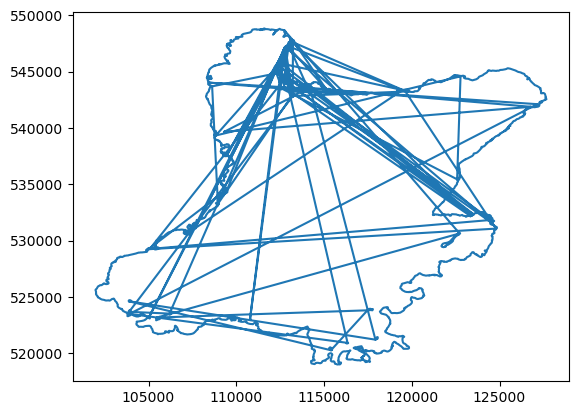

In [13]:
with fiona.open("loughNeagh/mapfiles/loughNeaghShapes.shp",
                "r") as shapefile:
    
    shapes = [transform.transform_geom('EPSG:27700', 'EPSG:32630',
                                       feature["geometry"]) for feature in shapefile]
    print(len(shapes))
    

    sf = shp.Reader("loughNeagh/mapfiles/loughNeaghShapes.shp")

    plt.figure()
    x = [i[0] for i in sf.shapeRecords()[4].shape.points[:]]
    y = [i[1] for i in sf.shapeRecords()[4].shape.points[:]]
    plt.plot(x,y)

    plt.show()
    
shapes = [shapes[4]] # indice of loughneagh